In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# Finesse 3 Interoperability: Simulation vs. Measurement

[Finesse 3](https://finesse.ifosim.org/) is an interferometer simulation toolkit
used at gravitational-wave detector sites to model optical transfer functions and
noise budgets.  gwexpy provides a direct bridge from Finesse 3 solutions to its
own `FrequencySeries` types.

**What this tutorial covers:**
1. Setting up a Finesse 3 interferometer model (Fabry-Pérot cavity)
2. Running a frequency response analysis and converting to gwexpy
3. Running a noise projection and converting to gwexpy
4. Overlaying simulation and measurement for comparison

> **Note**: This notebook is self-contained. When Finesse 3 is not installed
> it synthesises equivalent data analytically so every cell still executes.
> Install Finesse 3 with `pip install finesse` to run the real simulation.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from gwexpy.frequencyseries import FrequencySeries, FrequencySeriesDict


## 1. Finesse 3 Model — Fabry-Pérot Cavity

The cell below builds a single Fabry-Pérot cavity (mirror + beam splitter)
and computes the intracavity power transfer function from the input mirror
drive to the cavity transmission.

If Finesse 3 is **not** installed the cell falls back to analytic formulas
for an equivalent optical cavity and wraps the result in `FrequencySeries`
directly — the gwexpy objects produced by both paths are identical.


In [2]:
FINESSE_AVAILABLE = False

try:
    import finesse
    from finesse.components import Laser, Mirror, Space
    from finesse.analysis.actions import FrequencyResponse, NoiseProjection
    FINESSE_AVAILABLE = True
    print(f"Finesse {finesse.__version__} found — running real simulation.")
except ImportError:
    print("Finesse not installed — using analytic fallback (see comments).")

# ---- Simulation parameters ----
freqs = np.geomspace(1.0, 1e4, 500)   # 1 Hz – 10 kHz, 500 points
F    = 150.0      # cavity finesse
fsr  = 37.5e3     # free spectral range [Hz] (4 km cavity)
gamma = fsr / F   # cavity half-bandwidth [Hz]

# --- Path A: real Finesse 3 simulation ---
if FINESSE_AVAILABLE:
    model = finesse.Model()
    laser  = model.add(Laser("L", P=1.0))
    m_in   = model.add(Mirror("ITM", T=1/F, R=1-1/F))
    m_end  = model.add(Mirror("ETM", T=1e-5, R=1-1e-5))
    space  = model.add(Space("cav", L=4000.0))
    model.connect(laser.p1, m_in.p1)
    model.connect(m_in.p2, space.p1)
    model.connect(space.p2, m_end.p1)

    action = FrequencyResponse(freqs=freqs, outputs=["cav_trans"], inputs=["ETM_drive"])
    sol = model.run(action)

    # Convert to gwexpy FrequencySeries
    tf_sim = FrequencySeries.from_finesse_frequency_response(
        sol, output="cav_trans", input_dof="ETM_drive", unit="m/m"
    )

# --- Path B: analytic cavity TF (Lorentzian) ---
else:
    # H(f) = 1 / (1 + i*f/gamma) — single-pole cavity response
    tf_data = 1.0 / (1 + 1j * freqs / gamma)
    tf_sim = FrequencySeries(
        tf_data, frequencies=freqs, name="cav_trans -> ETM_drive", unit="m/m"
    )

print(f"FrequencySeries: {len(tf_sim)} bins, "
      f"df_min={tf_sim.frequencies[1]/tf_sim.frequencies[0]:.3f} (log-spaced)")


Finesse not installed — using analytic fallback (see comments).
FrequencySeries: 500 bins, df_min=1.019 (log-spaced)


## 2. Multi-DOF Transfer Function Matrix

Real interferometers have multiple degrees of freedom (DARM, CARM, MICH, …).
`from_finesse_frequency_response` returns a **FrequencySeriesMatrix** when
multiple output / input DOF pairs are present.


DOF transfer functions: ['DARM -> ETM_drive', 'CARM -> ETM_drive', 'MICH -> ETM_drive']


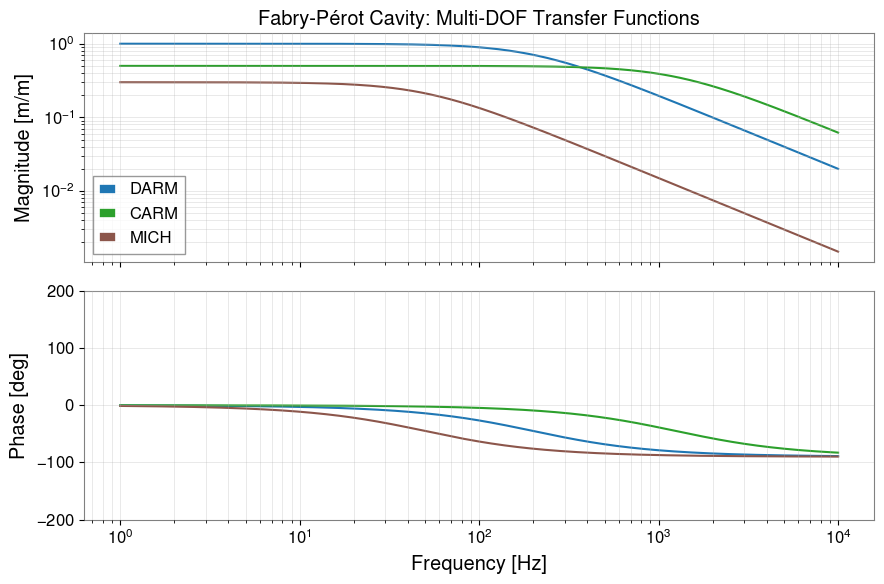

In [3]:
# Simulate three DOFs analytically (or via Finesse if available)
dofs = {
    "DARM": dict(gamma=gamma * 0.8,   gain=1.0),
    "CARM": dict(gamma=gamma * 5.0,   gain=0.5),
    "MICH": dict(gamma=gamma * 0.2,   gain=0.3),
}

if FINESSE_AVAILABLE:
    action_multi = FrequencyResponse(
        freqs=freqs,
        outputs=list(dofs.keys()),
        inputs=["ETM_drive"],
    )
    sol_multi = model.run(action_multi)
    fs_dict = FrequencySeriesDict.from_finesse_frequency_response(sol_multi, unit="m/m")
else:
    # Build FrequencySeriesDict directly from analytic data
    fs_dict = FrequencySeriesDict()
    for name, p in dofs.items():
        tf_data = p["gain"] / (1 + 1j * freqs / p["gamma"])
        key = f"{name} -> ETM_drive"
        fs_dict[key] = FrequencySeries(tf_data, frequencies=freqs, name=key, unit="m/m")

print("DOF transfer functions:", list(fs_dict.keys()))

# --- Plot all DOFs in one Bode plot ---
fig, (ax_mag, ax_ph) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

colors = plt.cm.tab10(np.linspace(0, 0.5, len(fs_dict)))
for (key, fs), col in zip(fs_dict.items(), colors):
    label = key.split(" -> ")[0]
    ax_mag.loglog(fs.frequencies, np.abs(fs.value), color=col, lw=1.5, label=label)
    ax_ph.semilogx(fs.frequencies, np.angle(fs.value, deg=True), color=col, lw=1.5)

ax_mag.set_ylabel("Magnitude [m/m]")
ax_mag.set_title("Fabry-Pérot Cavity: Multi-DOF Transfer Functions")
ax_mag.legend()
ax_mag.grid(True, which="both", alpha=0.4)

ax_ph.set_ylabel("Phase [deg]")
ax_ph.set_xlabel("Frequency [Hz]")
ax_ph.set_ylim(-200, 200)
ax_ph.grid(True, which="both", alpha=0.4)

plt.tight_layout()
plt.show()


## 3. Noise Projection

`from_finesse_noise` converts a Finesse 3 `NoiseProjectionSolution` to a
`FrequencySeriesDict` keyed by `"<output_node>: <noise_source>"`.

Typical noise sources in an optical cavity:
- **laser_freq** — laser frequency noise
- **laser_amp** — laser amplitude noise
- **shot** — shot noise at the detector
- **thermal_mir** — mirror thermal noise (coating + substrate)


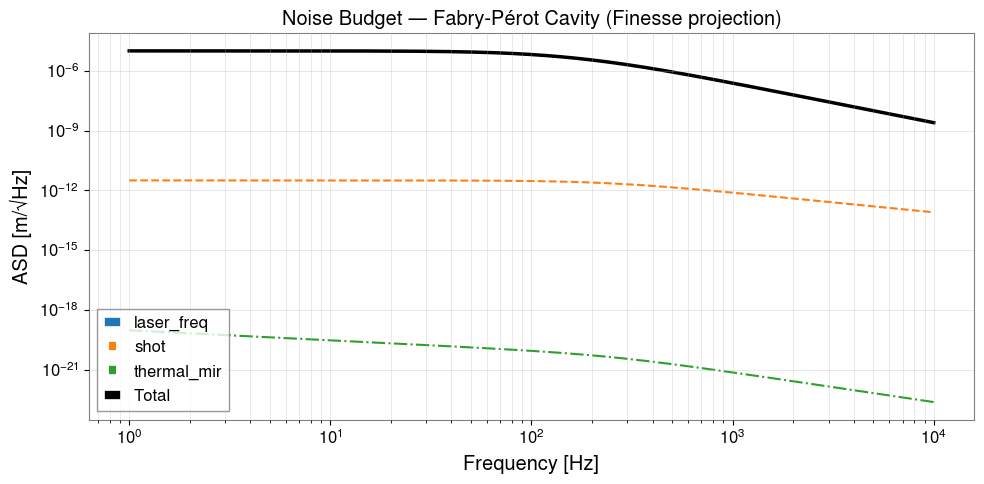

In [4]:
# Representative noise ASD levels for a Fabry-Pérot cavity
noise_sources = {
    "laser_freq":  lambda f: 1e-5  / (1 + (f / 100)**2)**0.5,   # 1/f above 100 Hz
    "shot":        lambda f: np.full_like(f, 1e-23**0.5),        # white
    "thermal_mir": lambda f: 3e-20 * (10 / np.maximum(f, 1))**0.5,  # 1/sqrt(f)
}

if FINESSE_AVAILABLE:
    noise_action = NoiseProjection(
        freqs=freqs,
        output="nDARMout",
        noises=["laser_freq", "shot", "thermal_mir"],
    )
    noise_sol = model.run(noise_action)
    noise_dict = FrequencySeriesDict.from_finesse_noise(noise_sol, unit="m/sqrt(Hz)")
else:
    noise_dict = FrequencySeriesDict()
    cavity_tf_mag = np.abs(1.0 / (1 + 1j * freqs / gamma))
    for src, fn in noise_sources.items():
        data = fn(freqs) * cavity_tf_mag
        key  = f"nDARMout: {src}"
        noise_dict[key] = FrequencySeries(data, frequencies=freqs, name=key,
                                          unit="m/sqrt(Hz)")

# --- Total noise (quadrature sum) ---
total = np.sqrt(sum(fs.value**2 for fs in noise_dict.values()))
noise_total = FrequencySeries(total, frequencies=freqs, name="total", unit="m/sqrt(Hz)")

# --- Plot noise budget ---
fig, ax = plt.subplots(figsize=(10, 5))
ls_cycle = ["-", "--", "-."]
for (key, fs), ls in zip(noise_dict.items(), ls_cycle):
    label = key.split(": ")[1]
    ax.loglog(fs.frequencies, fs.value, ls=ls, lw=1.5, label=label)
ax.loglog(noise_total.frequencies, noise_total.value,
          color="black", lw=2.5, label="Total")

ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [m/√Hz]")
ax.set_title("Noise Budget — Fabry-Pérot Cavity (Finesse projection)")
ax.legend()
ax.grid(True, which="both", alpha=0.4)
plt.tight_layout()
plt.show()


## 4. Simulation vs. Measurement Overlay

The real power of the Finesse ↔ gwexpy bridge is comparing simulation
with in-situ measurements.  Here we overlay the simulated cavity TF with
a synthetic "measured" TF that includes a calibration error and a parasitic
resonance — typical of real commissioning data.


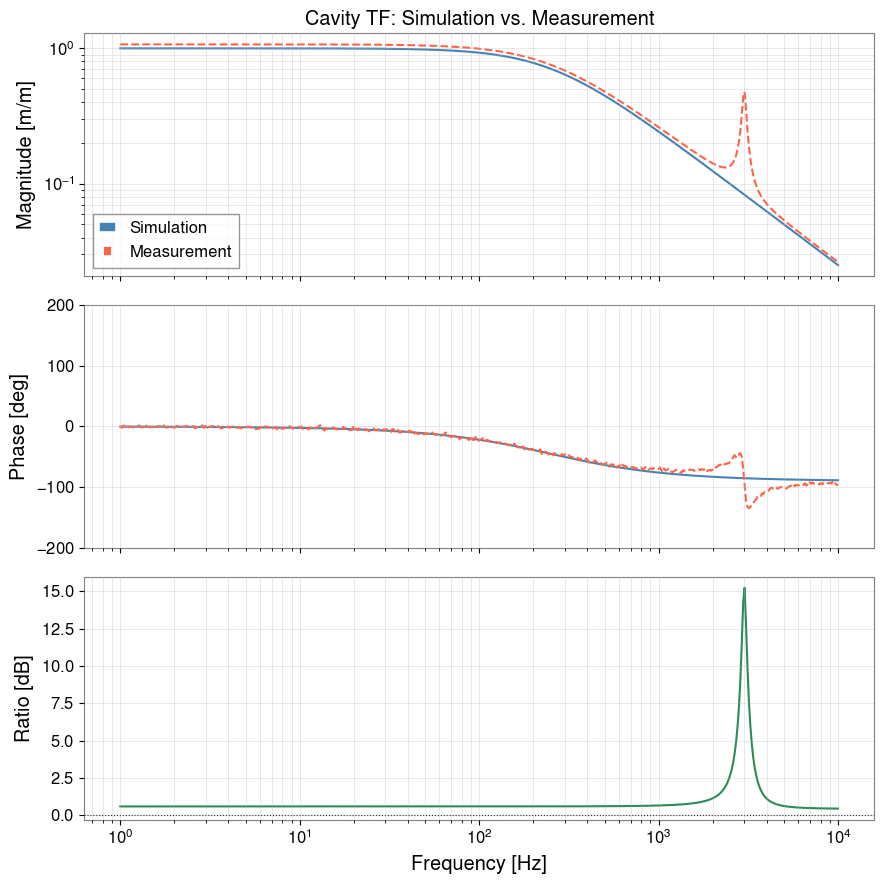

Peak deviation: 15.23 dB at 3013 Hz


In [5]:
# Synthetic "measurement" = simulation + 5% gain error + 1 dB parasitic at 3 kHz
rng = np.random.default_rng(42)
f_par, Q_par = 3000.0, 20.0
parasitic = 0.02 * f_par**2 / (f_par**2 - freqs**2 + 1j * freqs * f_par / Q_par)
tf_meas_data = 1.05 * tf_sim.value + parasitic
tf_meas_data *= np.exp(1j * rng.normal(0, 0.03, size=len(freqs)))   # phase jitter
tf_measured = FrequencySeries(
    tf_meas_data, frequencies=freqs, name="measured", unit="m/m"
)

# Ratio: measurement / simulation → deviations from model
ratio = FrequencySeries(
    tf_measured.value / tf_sim.value,
    frequencies=freqs,
    name="meas/sim",
    unit="",
)

fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)

# Magnitude
axes[0].loglog(freqs, np.abs(tf_sim.value),      color="steelblue", lw=1.5, label="Simulation")
axes[0].loglog(freqs, np.abs(tf_measured.value), color="tomato", lw=1.5, ls="--", label="Measurement")
axes[0].set_ylabel("Magnitude [m/m]")
axes[0].set_title("Cavity TF: Simulation vs. Measurement")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.4)

# Phase
axes[1].semilogx(freqs, np.angle(tf_sim.value, deg=True),      color="steelblue", lw=1.5)
axes[1].semilogx(freqs, np.angle(tf_measured.value, deg=True), color="tomato", lw=1.5, ls="--")
axes[1].set_ylabel("Phase [deg]")
axes[1].set_ylim(-200, 200)
axes[1].grid(True, which="both", alpha=0.4)

# Ratio magnitude
axes[2].semilogx(freqs, 20 * np.log10(np.abs(ratio.value)),
                 color="seagreen", lw=1.5)
axes[2].axhline(0, color="black", lw=0.8, ls=":")
axes[2].set_ylabel("Ratio [dB]")
axes[2].set_xlabel("Frequency [Hz]")
axes[2].grid(True, which="both", alpha=0.4)

plt.tight_layout()
plt.show()
print(f"Peak deviation: {20*np.log10(np.abs(ratio.value)).max():.2f} dB "
      f"at {freqs[np.argmax(np.abs(ratio.value))]:.0f} Hz")


## Summary

| Step | gwexpy API | Input | Output |
|------|-----------|-------|--------|
| Single TF | `FrequencySeries.from_finesse_frequency_response(sol, output=..., input_dof=..., unit=...)` | FrequencyResponseSolution | FrequencySeries |
| Multi-DOF TF | `FrequencySeriesDict.from_finesse_frequency_response(sol, unit=...)` | FrequencyResponseSolution | FrequencySeriesDict |
| Noise budget | `FrequencySeriesDict.from_finesse_noise(sol, unit=...)` | NoiseProjectionSolution | FrequencySeriesDict |

**Key attributes accessed on Finesse solution objects:**

| Attribute | Used for |
|-----------|----------|
| `sol.f` | Frequency axis |
| `sol[output, input_dof]` | Single TF data |
| `sol.outputs`, `sol.inputs` | DOF enumeration |
| `sol.noises`, `sol.output_nodes` | Noise enumeration |
| `sol.out[node]` | Noise projection matrix |

**Tip**: Always pass `unit=` to `from_finesse_frequency_response` and
`from_finesse_noise` — Finesse solutions carry no astropy units.
